# Donut Model Benchmark Analysis

Loads results from `../results/exp0*.json` and produces:
1. Component latency breakdown — preprocess / encode / decode (exp01)
2. Decoder linearity — decode_ms vs capped sequence length (exp04)
3. Batch throughput curves — samples/sec and tok/s vs batch size (exp02)
4. **Stacked latency per batch size** — absolute, per-image, and 100% (exp02)
5. Encoder stage breakdown — ms and % (exp03)
6. Decoder layer breakdown — ms/tok and % (exp03)
7. Memory scaling — encode vs decode peak vs batch size (exp02)
8. Token-length distribution — histogram of output lengths (exp01)

In [2]:
import json
import statistics
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

RESULTS = Path('../results')
PLOTS = Path('.')

COLORS = {
    'preprocess': '#4C72B0',
    'encode':     '#DD8452',
    'decode':     '#55A868',
    'overhead':   '#C7C7C7',
}

def load(pattern: str) -> list[dict]:
    paths = sorted(RESULTS.glob(pattern))
    if not paths:
        print(f'  [warn] no files match {RESULTS}/{pattern}')
    return [json.loads(p.read_text()) for p in paths]

print('Results directory:', RESULTS.resolve())

Results directory: /raid/home/students/fotis/Projects/inference/results


## 1. Component latency breakdown (Exp01, batch=1)

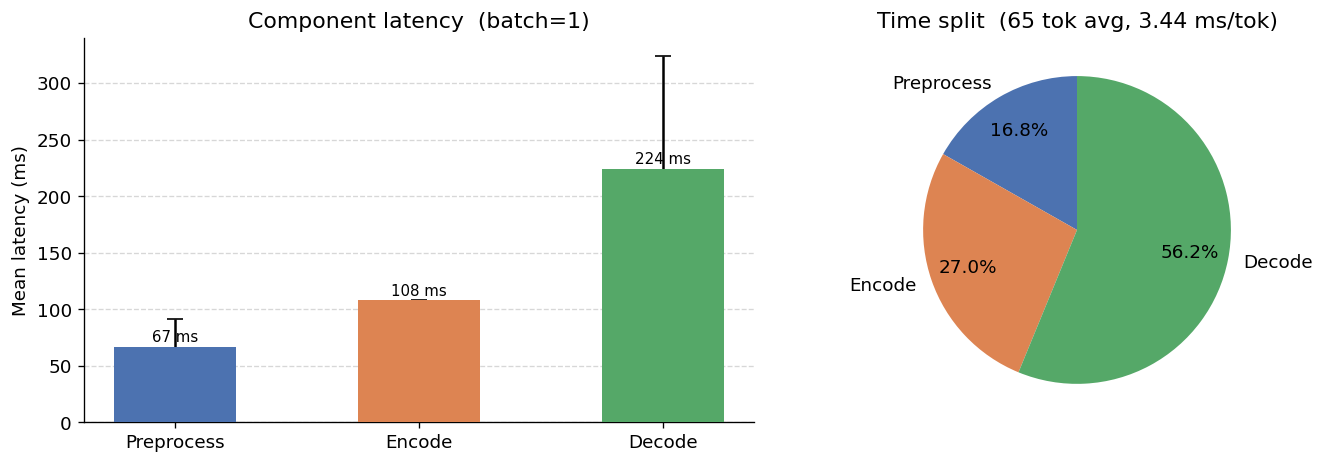

  encode peak  : 746 MB
  decode peak  : 452 MB
  decode       : 3.443 ms/tok  →  291 tok/s


In [3]:
data = load('exp01_component_latency.json')
if not data:
    print('Run exp01 first: bash experiments/exp01_component_latency.sh')
else:
    d = data[0]
    s = d['summary']

    # Use decode_ms.mean directly — not the approximation dec_ms_per_token * mean_n_tok,
    # which equals E[dec] only when dec/tok and tok are uncorrelated.
    labels = ['Preprocess', 'Encode', 'Decode']
    values = [
        s['preprocess_ms']['mean'],
        s['encode_ms']['mean'],
        s['decode_ms']['mean'],
    ]
    errors = [
        s['preprocess_ms']['std'],
        s['encode_ms']['std'],
        s['decode_ms']['std'],
    ]
    colors = [COLORS['preprocess'], COLORS['encode'], COLORS['decode']]
    n_tok = s['n_tokens']['mean']
    mpt   = s['decode_ms_per_token']['mean']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax = axes[0]
    bars = ax.bar(labels, values, color=colors, width=0.5, zorder=3)
    ax.errorbar(labels, values, yerr=errors, fmt='none', color='black', capsize=5, linewidth=1.5)
    ax.set_ylabel('Mean latency (ms)')
    ax.set_title('Component latency  (batch=1)')
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 2, f'{v:.0f} ms',
                ha='center', va='bottom', fontsize=9)

    ax = axes[1]
    ax.pie(values, labels=labels, colors=colors, autopct='%1.1f%%',
           startangle=90, pctdistance=0.75)
    ax.set_title(f'Time split  ({n_tok:.0f} tok avg, {mpt:.2f} ms/tok)')

    plt.tight_layout()
    plt.savefig(PLOTS / 'plot01_component_latency.png', bbox_inches='tight')
    plt.show()
    print(f"  encode peak  : {s['encode_peak_gpu_mb']:.0f} MB")
    print(f"  decode peak  : {s['decode_peak_gpu_mb']:.0f} MB")
    print(f"  decode       : {mpt:.3f} ms/tok  →  {s['tokens_per_sec']:.0f} tok/s")

## 2. Decoder linearity validation (Exp04)

Generation capped at `--max-new-tokens` values to produce controlled sequence lengths.
With KV-cache, each decoding step is O(1), so decode_ms should be linear in n_tokens
and ms/token should be **flat** across all cap values.

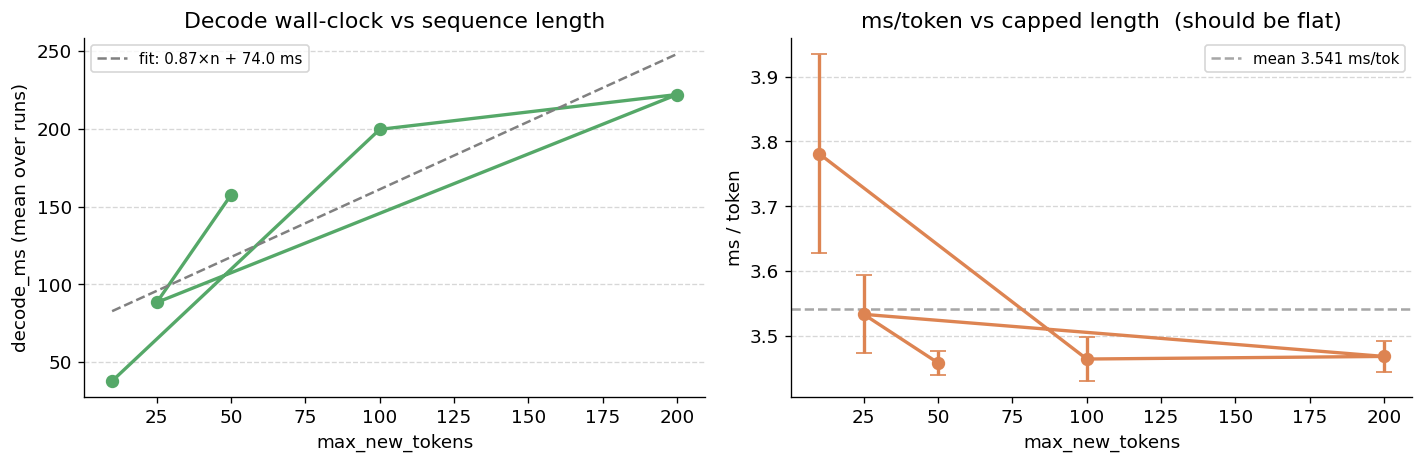

In [4]:
data = load('exp04_decoder_maxtok*.json')
if not data:
    print('Run exp04 first: bash experiments/exp04_decoder_scaling.sh')
else:
    max_toks = [d['args']['max_new_tokens'] for d in data]
    dec_ms   = [d['summary']['decode_ms']['mean'] for d in data]
    mpt      = [d['summary']['decode_ms_per_token']['mean'] for d in data]
    mpt_std  = [d['summary']['decode_ms_per_token']['std'] for d in data]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax = axes[0]
    ax.plot(max_toks, dec_ms, 'o-', color=COLORS['decode'], linewidth=2, markersize=7)
    if len(max_toks) >= 2:
        coeffs = np.polyfit(max_toks, dec_ms, 1)
        x_fit = np.linspace(min(max_toks), max(max_toks), 100)
        ax.plot(x_fit, np.polyval(coeffs, x_fit), '--', color='gray',
                label=f'fit: {coeffs[0]:.2f}×n + {coeffs[1]:.1f} ms')
        ax.legend(fontsize=9)
    ax.set_xlabel('max_new_tokens')
    ax.set_ylabel('decode_ms (mean over runs)')
    ax.set_title('Decode wall-clock vs sequence length')
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)

    ax = axes[1]
    ax.errorbar(max_toks, mpt, yerr=mpt_std, fmt='o-', color=COLORS['encode'],
                linewidth=2, markersize=7, capsize=5)
    grand_mean = statistics.mean(mpt)
    ax.axhline(grand_mean, color='gray', linestyle='--', alpha=0.7,
               label=f'mean {grand_mean:.3f} ms/tok')
    ax.set_xlabel('max_new_tokens')
    ax.set_ylabel('ms / token')
    ax.set_title('ms/token vs capped length  (should be flat)')
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig(PLOTS / 'plot02_decoder_linearity.png', bbox_inches='tight')
    plt.show()

## 3. Batch throughput curves (Exp02)

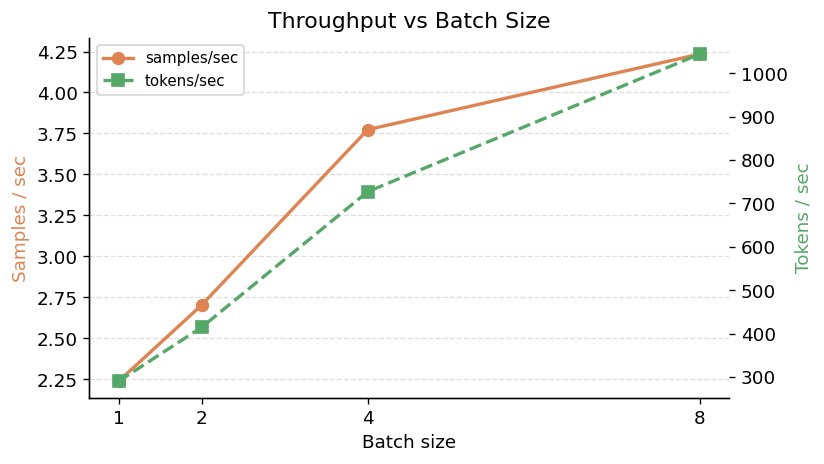

In [5]:
data = load('exp02_batch_bs*.json')
if not data:
    print('Run exp02 first: bash experiments/exp02_batch_sweep.sh')
else:
    bs_vals = [d['args']['batch_size'] for d in data]
    sps     = [d['summary']['samples_per_sec'] for d in data]
    tps     = [d['summary']['tokens_per_sec'] for d in data]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax2 = ax.twinx()
    l1, = ax.plot(bs_vals, sps, 'o-', color=COLORS['encode'], linewidth=2, markersize=7, label='samples/sec')
    l2, = ax2.plot(bs_vals, tps, 's--', color=COLORS['decode'], linewidth=2, markersize=7, label='tokens/sec')
    ax.set_xlabel('Batch size')
    ax.set_ylabel('Samples / sec', color=COLORS['encode'])
    ax2.set_ylabel('Tokens / sec', color=COLORS['decode'])
    ax.set_title('Throughput vs Batch Size')
    ax.set_xticks(bs_vals)
    ax.legend(handles=[l1, l2], loc='upper left', fontsize=9)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.savefig(PLOTS / 'plot03_throughput_curves.png', bbox_inches='tight')
    plt.show()

## 4. Stacked latency breakdown per batch size (Exp02)

Each bar shows how the **total wall-clock time** is composed of its three phases.
The black dot on panel A marks the measured `e2e_ms` — it sits slightly above the
stack because there is a small unattributed overhead (Python scheduling, CUDA syncs
between phases, etc.).

- **Panel A** — absolute ms per batch: how long does one batch take?
- **Panel B** — ms per image (÷ batch_size): does per-image cost drop as batch grows?
- **Panel C** — 100% stacked: how does the fraction each phase occupies shift?

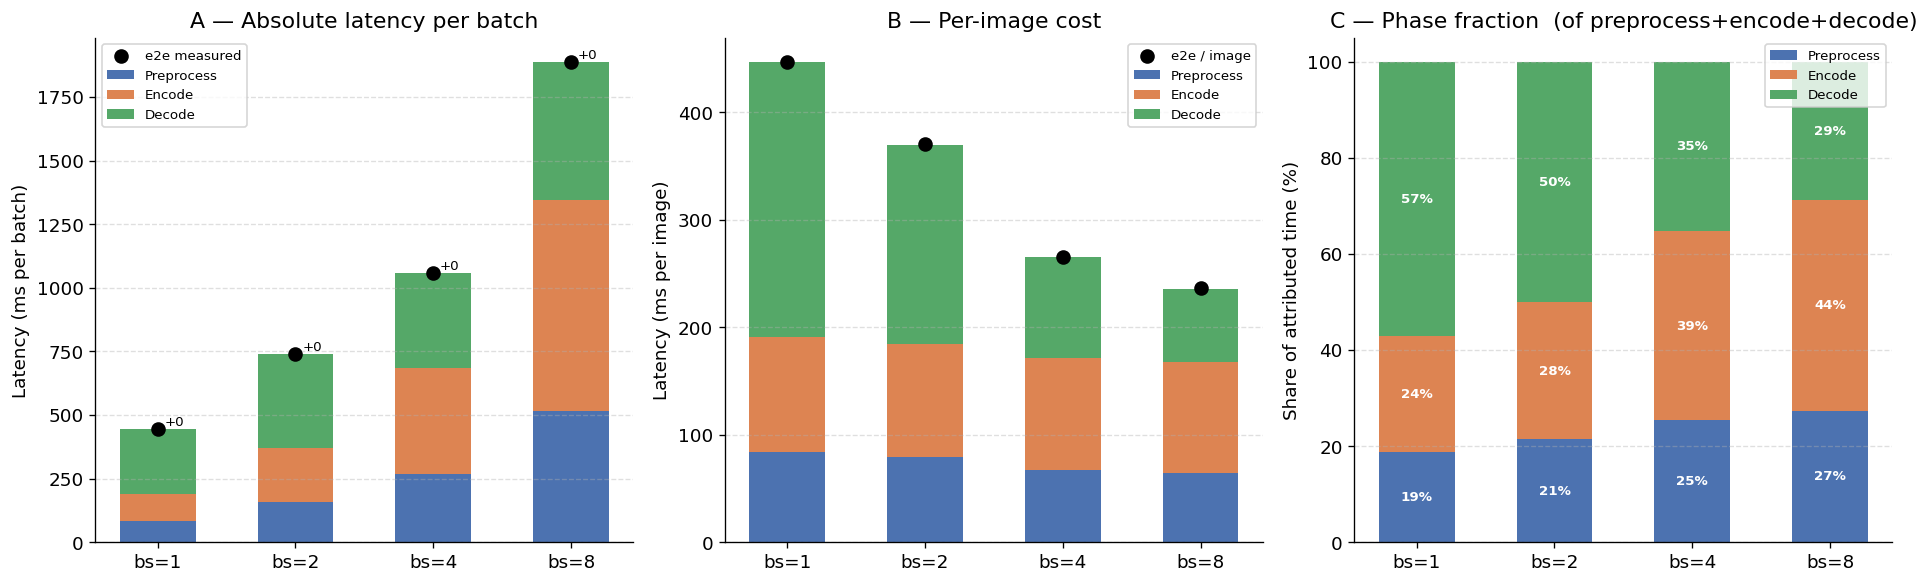

In [6]:
data = load('exp02_batch_bs*.json')
if not data:
    print('Run exp02 first: bash experiments/exp02_batch_sweep.sh')
else:
    bs_vals = [d['args']['batch_size'] for d in data]
    pre_ms  = [d['summary']['preprocess_ms']['mean'] for d in data]
    enc_ms  = [d['summary']['encode_ms']['mean'] for d in data]
    dec_ms  = [d['summary']['decode_ms']['mean'] for d in data]
    e2e_ms  = [d['summary']['e2e_ms']['mean'] for d in data]

    pre_std = [d['summary']['preprocess_ms']['std'] for d in data]
    enc_std = [d['summary']['encode_ms']['std'] for d in data]
    dec_std = [d['summary']['decode_ms']['std'] for d in data]

    # Per-image values
    pre_per = [p / b for p, b in zip(pre_ms, bs_vals)]
    enc_per = [e / b for e, b in zip(enc_ms, bs_vals)]
    dec_per = [d / b for d, b in zip(dec_ms, bs_vals)]
    e2e_per = [e / b for e, b in zip(e2e_ms, bs_vals)]

    # Percentage of attributed time (preprocess + encode + decode)
    stacks = [p + e + d for p, e, d in zip(pre_ms, enc_ms, dec_ms)]
    pre_pct = [100 * p / s for p, s in zip(pre_ms, stacks)]
    enc_pct = [100 * e / s for e, s in zip(enc_ms, stacks)]
    dec_pct = [100 * d / s for d, s in zip(dec_ms, stacks)]

    x = np.arange(len(bs_vals))
    xlabels = [f'bs={b}' for b in bs_vals]
    width = 0.55
    c_pre, c_enc, c_dec = COLORS['preprocess'], COLORS['encode'], COLORS['decode']

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # ── Panel A: absolute ms per batch ───────────────────────────────────────
    ax = axes[0]
    b1 = ax.bar(x, pre_ms, width, label='Preprocess', color=c_pre)
    b2 = ax.bar(x, enc_ms, width, bottom=pre_ms, label='Encode', color=c_enc)
    b3 = ax.bar(x, dec_ms, width,
                bottom=[p + e for p, e in zip(pre_ms, enc_ms)],
                label='Decode', color=c_dec)
    # Measured e2e as validation dot
    ax.scatter(x, e2e_ms, color='black', zorder=5, s=60, label='e2e measured')
    # Annotate overhead gap
    for xi, e2e, stack in zip(x, e2e_ms, stacks):
        gap = e2e - stack
        if gap > 0:
            ax.annotate(f'+{gap:.0f}', (xi, e2e), textcoords='offset points',
                        xytext=(4, 2), fontsize=8, color='black')
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels)
    ax.set_ylabel('Latency (ms per batch)')
    ax.set_title('A — Absolute latency per batch')
    ax.legend(fontsize=8, loc='upper left')
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)

    # ── Panel B: per-image ms ─────────────────────────────────────────────────
    ax = axes[1]
    ax.bar(x, pre_per, width, label='Preprocess', color=c_pre)
    ax.bar(x, enc_per, width, bottom=pre_per, label='Encode', color=c_enc)
    ax.bar(x, dec_per, width,
           bottom=[p + e for p, e in zip(pre_per, enc_per)],
           label='Decode', color=c_dec)
    ax.scatter(x, e2e_per, color='black', zorder=5, s=60, label='e2e / image')
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels)
    ax.set_ylabel('Latency (ms per image)')
    ax.set_title('B — Per-image cost')
    ax.legend(fontsize=8, loc='upper right')
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)

    # ── Panel C: 100% stacked ─────────────────────────────────────────────────
    ax = axes[2]
    ax.bar(x, pre_pct, width, label='Preprocess', color=c_pre)
    ax.bar(x, enc_pct, width, bottom=pre_pct, label='Encode', color=c_enc)
    ax.bar(x, dec_pct, width,
           bottom=[p + e for p, e in zip(pre_pct, enc_pct)],
           label='Decode', color=c_dec)
    # Annotate each segment with its percentage
    for xi, p, e, d, pp, ep, dp in zip(x, pre_ms, enc_ms, dec_ms, pre_pct, enc_pct, dec_pct):
        ax.text(xi, pp / 2,              f'{pp:.0f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
        ax.text(xi, pp + ep / 2,         f'{ep:.0f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
        ax.text(xi, pp + ep + dp / 2,    f'{dp:.0f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels)
    ax.set_ylabel('Share of attributed time (%)')
    ax.set_title('C — Phase fraction  (of preprocess+encode+decode)')
    ax.set_ylim(0, 105)
    ax.legend(fontsize=8, loc='upper right')
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)

    plt.tight_layout()
    plt.savefig(PLOTS / 'plot06_stacked_batch.png', bbox_inches='tight')
    plt.show()

## 5 & 6. Layer breakdown: encoder stages + decoder layers (Exp03)

/tmp/ipykernel_180223/614227212.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)


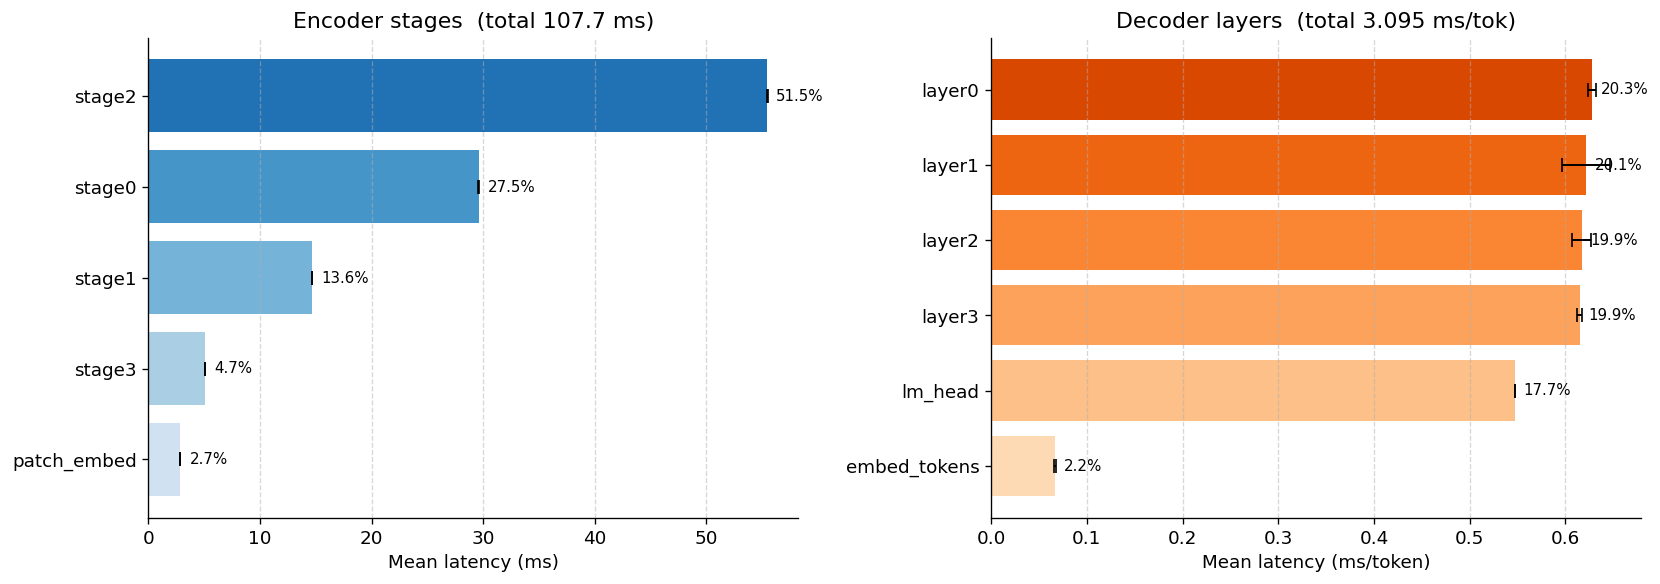

In [7]:
data = load('exp03_layer_breakdown.json')
if not data:
    print('Run exp03 first: bash experiments/exp03_layer_breakdown.sh')
else:
    d = data[0]
    enc = d['summary']['encoder']
    dec = d['summary']['decoder']

    enc_keys = sorted([k for k in enc if k != 'total'], key=lambda k: enc[k]['mean'], reverse=True)
    dec_keys = sorted([k for k in dec if k != 'total'], key=lambda k: dec[k]['mean'], reverse=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, max(5, max(len(enc_keys), len(dec_keys)) * 0.4 + 1)))

    def _hbar(ax, keys, summary, xlabel, title, cmap_name):
        means = [summary[k]['mean'] for k in keys]
        stds  = [summary[k]['std']  for k in keys]
        pcts  = [summary[k]['pct']  for k in keys]
        cmap = plt.cm.get_cmap(cmap_name)
        colors = [cmap(0.25 + 0.55 * i / max(len(keys) - 1, 1)) for i in range(len(keys))]
        bars = ax.barh(keys, means, xerr=stds, color=colors, align='center',
                       capsize=4, error_kw={'elinewidth': 1.2})
        for bar, pct, val in zip(bars, pcts, means):
            ax.text(val + max(means) * 0.015, bar.get_y() + bar.get_height() / 2,
                    f'{pct:.1f}%', va='center', fontsize=9)
        ax.set_xlabel(xlabel)
        ax.set_title(title)
        ax.xaxis.grid(True, linestyle='--', alpha=0.5)
        ax.invert_yaxis()

    _hbar(axes[0], enc_keys, enc,
          xlabel='Mean latency (ms)',
          title=f"Encoder stages  (total {enc['total']['mean']:.1f} ms)",
          cmap_name='Blues_r')
    _hbar(axes[1], dec_keys, dec,
          xlabel='Mean latency (ms/token)',
          title=f"Decoder layers  (total {dec['total']['mean']:.3f} ms/tok)",
          cmap_name='Oranges_r')

    plt.tight_layout()
    plt.savefig(PLOTS / 'plot04_layer_breakdown.png', bbox_inches='tight')
    plt.show()

## 7. Memory scaling vs batch size (Exp02)

Using exp02 data (30 runs per batch size — better statistics than the separate exp05 memory run).
Encode peak: activations only (KV-cache not yet allocated). Decode peak: full KV-cache grown.

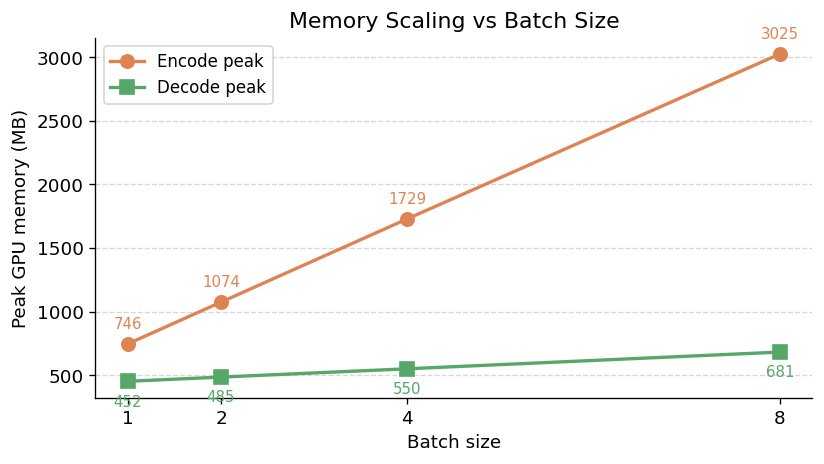

In [8]:
data = load('exp02_batch_bs*.json')
if not data:
    print('Run exp02 first: bash experiments/exp02_batch_sweep.sh')
else:
    bs_vals  = [d['args']['batch_size'] for d in data]
    enc_peak = [d['summary']['encode_peak_gpu_mb'] for d in data]
    dec_peak = [d['summary']['decode_peak_gpu_mb'] for d in data]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(bs_vals, enc_peak, 'o-', color=COLORS['encode'], linewidth=2, markersize=8, label='Encode peak')
    ax.plot(bs_vals, dec_peak, 's-', color=COLORS['decode'], linewidth=2, markersize=8, label='Decode peak')

    for xi, y_enc, y_dec in zip(bs_vals, enc_peak, dec_peak):
        ax.annotate(f'{y_enc:.0f}', (xi, y_enc), textcoords='offset points', xytext=(0, 9),
                    ha='center', fontsize=9, color=COLORS['encode'])
        ax.annotate(f'{y_dec:.0f}', (xi, y_dec), textcoords='offset points', xytext=(0, -15),
                    ha='center', fontsize=9, color=COLORS['decode'])

    ax.set_xlabel('Batch size')
    ax.set_ylabel('Peak GPU memory (MB)')
    ax.set_title('Memory Scaling vs Batch Size')
    ax.set_xticks(bs_vals)
    ax.legend(fontsize=10)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig(PLOTS / 'plot05_memory_scaling.png', bbox_inches='tight')
    plt.show()

## 8. Token-length distribution (Exp01)

The CORD-v2 test set has receipts with varying numbers of line items. The distribution
of output sequence lengths determines how much decode time variance we observe.
High variance → decode_ms_per_token is meaningful but raw decode_ms is not.

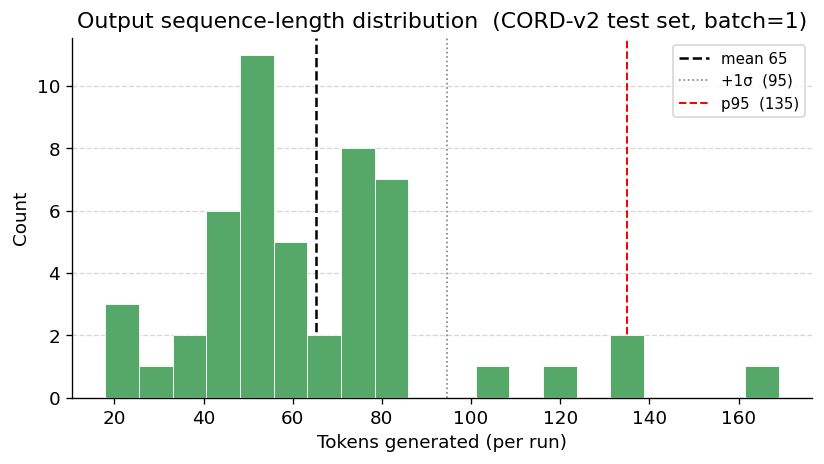

  n_tokens: mean=65  std=29  p95=135  range=18–169


In [9]:
data = load('exp01_component_latency.json')
if not data:
    print('Run exp01 first: bash experiments/exp01_component_latency.sh')
else:
    tokens = data[0]['runs']['n_tokens']
    mean_t = statistics.mean(tokens)
    std_t  = statistics.stdev(tokens) if len(tokens) > 1 else 0.0
    p95    = sorted(tokens)[int(0.95 * len(tokens))]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(tokens, bins=20, color=COLORS['decode'], edgecolor='white', linewidth=0.5, zorder=3)
    ax.axvline(mean_t, color='black', linestyle='--', linewidth=1.5,
               label=f'mean {mean_t:.0f}')
    ax.axvline(mean_t + std_t, color='gray', linestyle=':', linewidth=1,
               label=f'+1σ  ({mean_t + std_t:.0f})')
    ax.axvline(p95, color='red', linestyle='--', linewidth=1.2,
               label=f'p95  ({p95})')
    ax.set_xlabel('Tokens generated (per run)')
    ax.set_ylabel('Count')
    ax.set_title('Output sequence-length distribution  (CORD-v2 test set, batch=1)')
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)

    plt.tight_layout()
    plt.savefig(PLOTS / 'plot07_tokens_distribution.png', bbox_inches='tight')
    plt.show()
    print(f'  n_tokens: mean={mean_t:.0f}  std={std_t:.0f}  p95={p95}  range={min(tokens)}–{max(tokens)}')